In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lobster import *

In [2]:
message_path  = "data/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = "data/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
table1 = make_descriptive_table(df, K=5)
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df = normalize_by_aes(df, aes=aes, K=5)
df

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,P_-3,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5
0,34200.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1
1,34200.006462,0.000221,L,275500,4,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
2,34200.048864,0.042402,C,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
3,34200.048883,0.000020,C,275100,-1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
4,34200.048989,0.000106,L,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580346,57599.860444,0.011408,C,267200,1,72,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580347,57599.860635,0.000191,L,267000,-2,38,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580348,57599.870108,0.009473,C,267400,3,2,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580349,57599.939645,0.069536,L,267200,1,1,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98


### Prepare DataFrame for correct timings ###

In [3]:
def extract_price_changes(df, price_col="price", time_col="time"):
    d = df[df["type"] == "M"].copy()
    changed = d["price"].ne(d["price"].shift())
    d = d.loc[changed].reset_index(drop=True)
    
    d = d[[time_col, price_col]].copy()
    d["dp"] = d[price_col].diff()
    d = d.dropna().reset_index(drop=True)
    
    return d

In [4]:
pc = extract_price_changes(df)
pc

,time,price,dp
0,34200.441108,275100,-100.0
1,34200.649465,275300,200.0
2,34200.783992,275200,-100.0
3,34200.912227,275300,100.0
4,34200.989774,275250,-50.0
...,...,...,...
2785,57598.214818,267200,50.0
2786,57598.221989,267150,-50.0
2787,57598.401422,267200,50.0
2788,57598.408973,267150,-50.0


### Prepare DataFrame for Alternation and Continuation sequences ###

In [5]:
def compute_alternation_continuation(pc, tick_size=None):
    pc = pc.copy()
    
    if tick_size is None:
        tick_size = np.min(np.abs(pc["dp"]))
    
    pc["sign"] = np.sign(pc["dp"]).astype(int)
    pc["L"]    = (pc["dp"].abs() / tick_size).astype(int)

    pc["sign_prev"] = pc["sign"].shift()
    pc = pc.dropna().reset_index(drop=True)
    pc["sign_prev"] = pc["sign_prev"].astype(int)

    pc["is_cont"] = pc["sign"] == pc["sign_prev"]
    pc["is_alt"]  = pc["sign"] == -pc["sign_prev"]

    return pc

In [6]:
tick_size = np.min(np.abs(pc["dp"]))
pc = compute_alternation_continuation(pc)
pc

,time,price,dp,sign,L,sign_prev,is_cont,is_alt
0,34200.649465,275300,200.0,1,4,-1,False,True
1,34200.783992,275200,-100.0,-1,2,1,False,True
2,34200.912227,275300,100.0,1,2,-1,False,True
3,34200.989774,275250,-50.0,-1,1,1,False,True
4,34201.001788,275200,-50.0,-1,1,-1,True,False
...,...,...,...,...,...,...,...,...
2784,57598.214818,267200,50.0,1,1,1,True,False
2785,57598.221989,267150,-50.0,-1,1,1,False,True
2786,57598.401422,267200,50.0,1,1,-1,False,True
2787,57598.408973,267150,-50.0,-1,1,1,False,True


### Estimate  $\hat{\eta}_t = \sum_{k=1}^{m} \lambda_{\alpha,t,k} u_{\alpha,t,k}$  ###

with  $ \lambda_{\alpha,t,k} = \frac{N_{\alpha,t,k}^{(a)} + N_{\alpha,t,k}^{(c)}}{\sum_{j=1}^{m} \left[ N_{\alpha,t,j}^{(a)} + N_{\alpha,t,j}^{(c)} \right]} \text{  and  } u_{\alpha,t,k} = \frac{1}{2}\left(k\left(\frac{N_{\alpha,t,k}^{(c)}}{N_{\alpha,t,k}^{(a)}} - 1\right) + 1\right). $

In [7]:
def estimate_eta_hat(pc):
    results = []

    for k in sorted(pc["L"].unique()):
        sub = pc[pc["L"]==k]
        
        Nc = sub["is_cont"].sum()
        Na = sub["is_alt"].sum()
        
        if Na > 0:
            u_k = 0.5 * ( k*(Nc/Na - 1) + 1 )
        else :
            u_k = np.nan
        
        results.append({
                "k": k,
                "Nc": Nc,
                "Na": Na,
                "u_k": u_k,
                "N_total": Nc + Na
            })

    res = pd.DataFrame(results)
    res["lambda_k"] = res["N_total"] / res["N_total"].sum()
    
    eta_hat = np.nansum(res["lambda_k"] * res["u_k"])

    return res, eta_hat

### Efficient Price : $\hat{X}_{\tau_i} = P_{t_i} - \alpha(\frac{1}{2}-\hat\eta)sgn(P_{t_i} - P_{t_{i-1}})$ ##

In [8]:
def compute_efficient_price(pc, eta_hat, tick_size):
    pc = pc.copy()
    pc["X_hat"] = pc["price"] - tick_size * (0.5 - eta_hat) * pc["sign"]
    return pc

### Realized Volatility : $ \widehat{RV_t} = \sum_{i=1}^{N_{\alpha, t}}(\log(\hat{X}_{\tau_i}) - \log(\hat{X}_{\tau_i-1}))^2$

In [9]:
def compute_realized_variance(pc):
    # Calculate the log of the efficient price
    pc = pc.copy()
    pc['log_X_hat'] = np.log(pc['X_hat'])
    
    # Calculate the squared differences
    pc['log_return_sq'] = pc['log_X_hat'].diff() ** 2
    
    # Sum them to get the Realized Variance (RV)
    rv = pc['log_return_sq'].sum()
    
    return rv

### Rolling Window computing $\hat\eta_t$, $\hat{X}_{\tau_i}$ and $\widehat{RV_t}$ ###

In [10]:
def rolling_microstructure_volatility(
    pc,
    window_seconds=600,
    tick_size=None,
    min_price_changes=30,
    annualization_seconds=252 * 6.5 * 60 * 60
):
    """
    Returns a row-level dataframe in the same style as your screenshot:
    one row per price-changing transaction, with both static and rolling columns.
    """

    df = pc.copy().reset_index(drop=True)

    # Infer tick size if needed
    if tick_size is None:
        tick_size = np.min(np.abs(df["dp"][df["dp"] != 0]))

    # Ensure the base microstructure columns exist
    if "sign" not in df.columns or "L" not in df.columns or \
       "sign_prev" not in df.columns or "is_cont" not in df.columns or "is_alt" not in df.columns:
        df = compute_alternation_continuation(df, tick_size=tick_size)

    times = df["time"].values

    eta_hat_rolling = []
    rolling_rv = []
    annualized_vol = []
    X_hat_rolling = []

    left = 0
    for right in range(len(df)):
        t_end = times[right]
        t_start = t_end - window_seconds

        while left < len(times) and times[left] < t_start:
            left += 1

        window_df = df.iloc[left:right + 1].copy()

        # Default NaNs if not enough data
        eta_val = np.nan
        rv_val = np.nan
        vol_val = np.nan
        xhat_val = np.nan

        if len(window_df) >= min_price_changes:
            # Recompute alternation/continuation INSIDE the window
            # to stay methodologically consistent with Code 2
            window_ac = compute_alternation_continuation(
                window_df[["time", "price", "dp"]].copy(),
                tick_size=tick_size
            )

            if len(window_ac) >= max(10, min_price_changes - 1):
                _, eta_window = estimate_eta_hat(window_ac)

                if np.isfinite(eta_window):
                    # Rolling efficient price on that window
                    window_eff = compute_efficient_price(window_ac, eta_window, tick_size)

                    # Rolling RV on that window
                    rv_window = compute_realized_variance(window_eff)

                    ann_var = rv_window * (annualization_seconds / window_seconds)
                    vol_window = np.sqrt(ann_var)

                    # Need the rolling efficient price aligned to the current row
                    # window_ac loses the first row because of shift(), so the last row
                    # in window_eff corresponds to the current right endpoint.
                    eta_val = eta_window
                    rv_val = rv_window
                    vol_val = vol_window
                    xhat_val = window_eff["X_hat"].iloc[-1]

        eta_hat_rolling.append(eta_val)
        rolling_rv.append(rv_val)
        annualized_vol.append(vol_val)
        X_hat_rolling.append(xhat_val)

    # Attach rolling columns
    df["eta_hat_rolling"] = eta_hat_rolling
    df["X_hat_rolling"] = X_hat_rolling
    df["log_X_hat_rolling"] = np.log(df["X_hat_rolling"])
    df["log_return_sq"] = df["log_X_hat_rolling"].diff() ** 2
    df["rolling_RV"] = rolling_rv
    df["annualized_vol"] = annualized_vol

    df = df.dropna().reset_index(drop=True)
    return df

In [11]:
pc_rolling = rolling_microstructure_volatility(pc, window_seconds=5*60, tick_size=50, min_price_changes=0)
pc_rolling

,time,price,dp,sign,L,sign_prev,is_cont,is_alt,eta_hat_rolling,X_hat_rolling,log_X_hat_rolling,log_return_sq,rolling_RV,annualized_vol
0,34201.425350,275300,-100.0,-1,2,1,False,True,0.219697,275314.015152,12.525668,8.297815e-08,6.532063e-07,0.113311
1,34201.665038,275200,-100.0,-1,2,-1,True,False,0.388889,275205.555556,12.525274,1.552567e-07,9.337393e-07,0.135475
2,34201.671832,275300,100.0,1,2,-1,False,True,0.258974,275287.948718,12.525573,8.960618e-08,8.916616e-07,0.132388
3,34202.163063,275200,-100.0,-1,2,1,False,True,0.166667,275216.666667,12.525314,6.706539e-08,8.652818e-07,0.130415
4,34202.208668,275400,200.0,1,4,-1,False,True,0.055556,275377.777778,12.525899,3.424896e-07,1.085147e-06,0.146047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2730,57598.214818,267200,50.0,1,1,1,True,False,0.161019,267183.050929,12.495689,3.525614e-08,4.757017e-06,0.305784
2731,57598.221989,267150,-50.0,-1,1,1,False,True,0.159959,267167.002062,12.495629,3.608254e-09,4.749900e-06,0.305555
2732,57598.401422,267200,50.0,1,1,-1,False,True,0.158913,267182.945652,12.495689,3.561071e-09,4.742882e-06,0.305329
2733,57598.408973,267150,-50.0,-1,1,1,False,True,0.157881,267167.105942,12.495630,3.514817e-09,4.735962e-06,0.305107


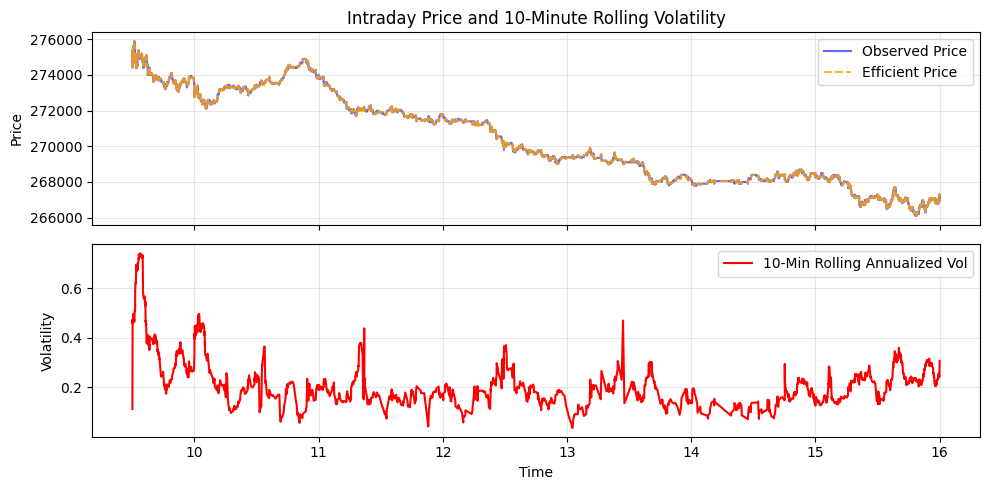

In [12]:
# Create a figure with two subplots that share the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Top panel: Observed Price vs Efficient Price
ax1.step(pc_rolling['time']/3600, pc_rolling['price'], label='Observed Price', color='blue', alpha=0.6)
ax1.step(pc_rolling['time']/3600, pc_rolling['X_hat_rolling'], label='Efficient Price', color='orange', alpha=0.8, linestyle='--')
ax1.set_ylabel('Price')
ax1.set_title('Intraday Price and 10-Minute Rolling Volatility')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Bottom panel: Rolling Annualized Volatility
ax2.plot(pc_rolling['time']/3600, pc_rolling['annualized_vol'], label='10-Min Rolling Annualized Vol', color='red')
ax2.set_xlabel('Time')
ax2.set_ylabel('Volatility')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Adjust layout to prevent overlap and display
plt.tight_layout()
plt.show()

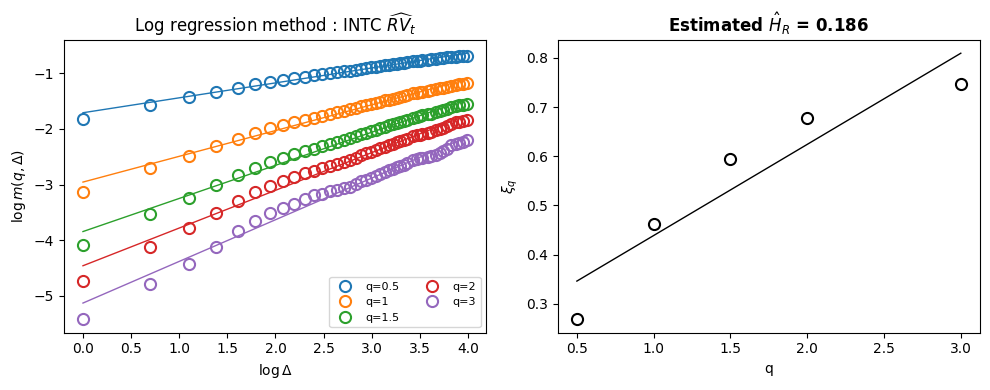

In [27]:
from functions_part2 import plot_scaling_and_xi

qs = np.array([0.5, 1.0, 1.5, 2.0, 3.0])
deltas = np.unique(np.round(np.logspace(0, 1.73, 100)).astype(int))
HR_sigma, xi_sigma, m_sigma = plot_scaling_and_xi(
    V=pc_rolling["annualized_vol"].values,
    deltas=deltas,
    qs=qs,
    title_left=r"Log regression method : INTC $\widehat{RV}_t$",
    title_right="Estimated",
    eps=1e-10,               # bump eps slightly, sigma can be tiny
    fit_intercept=True
)